# K-Means Clustering

In [16]:
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

In [17]:
!wget "https://drive.google.com/uc?export=download&id=1lEccW5Y5_2z00VRtLGOAJOAU6YA9fl6W" -O E-commerce.csv

--2024-07-05 04:50:36--  https://drive.google.com/uc?export=download&id=1lEccW5Y5_2z00VRtLGOAJOAU6YA9fl6W
Resolving drive.google.com (drive.google.com)... 142.251.163.101, 142.251.163.139, 142.251.163.102, ...
Connecting to drive.google.com (drive.google.com)|142.251.163.101|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1lEccW5Y5_2z00VRtLGOAJOAU6YA9fl6W&export=download [following]
--2024-07-05 04:50:36--  https://drive.usercontent.google.com/download?id=1lEccW5Y5_2z00VRtLGOAJOAU6YA9fl6W&export=download
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 142.251.16.132, 2607:f8b0:4004:c17::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|142.251.16.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 139827 (137K) [application/octet-stream]
Saving to: ‘E-commerce.csv’

E-commerce.csv      100%[===================>] 136.55K  --.-K

In [18]:
df = pd.read_csv('E-commerce.csv')
# df.head()

In [19]:
df.head()

,ID,n_clicks,n_visits,amount_spent,amount_discount,days_since_registration,profile_information
0,1476,130,65,213.905831,31.600751,233,235
1,1535,543,46,639.223004,5.689175,228,170
2,1807,520,102,1157.402763,844.321606,247,409
3,1727,702,83,1195.903634,850.041757,148,200
4,1324,221,84,180.754616,64.283300,243,259


In [20]:
X = df.copy()
X.drop('ID', inplace=True, axis=1)
X.describe()

,n_clicks,n_visits,amount_spent,amount_discount,days_since_registration,profile_information
count,2500.00000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000
mean,408.68000,94.475600,1445.090745,388.508637,200.973600,201.040400
std,186.41409,38.866356,1167.663473,487.143968,99.136618,100.139213
min,50.00000,10.000000,0.000000,0.000000,0.000000,0.000000
25%,274.75000,67.000000,609.618538,56.298615,130.000000,132.000000
50%,378.00000,92.000000,1036.189112,137.454623,200.000000,201.000000
75%,522.00000,119.000000,1949.270949,679.540536,268.000000,270.000000
max,1246.00000,259.000000,6567.402267,2428.406527,514.000000,585.000000


In [21]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaler.fit(X)
X=scaler.transform(X)

---
###  DBSCAN

https://www.naftaliharris.com/blog/visualizing-dbscan-clustering/

https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/016/028/original/ezgif-5-dc143adcc5_%281%29.mp4?1665381737

In [22]:
# min_samples>d+1 ()2*d

In [23]:
from sklearn.cluster import DBSCAN
dbsc = DBSCAN(eps = 0.15, min_samples = 24).fit(X)

In [24]:
pd.Series(dbsc.labels_).value_counts(normalize=True)

-1    0.6052
 0    0.3384
 1    0.0564
Name: proportion, dtype: float64

In [25]:
clusters = pd.DataFrame(X, columns=df.columns[1:])
clusters['dbsc'] = dbsc.labels_
clusters['dbsc'].unique()

array([ 0, -1,  1])

In [26]:
import plotly.express as px

fig = px.scatter_3d(clusters, x='n_clicks', y='amount_spent', z='amount_discount', color='dbsc', width=600, height=600)
fig.update_traces(marker=dict(size=2), selector=dict(mode='markers'))
fig.show()

In [27]:
!gdown 1c6cjIULb3-fjyaVITdui_AFcKMz_lxlg

Downloading...
From: https://drive.google.com/uc?id=1c6cjIULb3-fjyaVITdui_AFcKMz_lxlg
To: /content/AnomalyDetection.csv
100% 33.0k/33.0k [00:00<00:00, 66.6MB/s]


In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams["figure.figsize"] = (12,8)

In [29]:
df = pd.read_csv('/content/AnomalyDetection.csv')
df.head()

,Mileage,Price
0,54.282388,67.967708
1,17.331911,70.023637
2,36.548113,68.080455
3,42.567541,71.058755
4,5.608853,57.822432


In [30]:
df.describe()

,Mileage,Price
count,908.000000,908.000000
mean,45.869736,77.555036
std,30.598219,19.275677
min,1.398964,20.000000
25%,25.415487,64.435773
50%,34.599453,73.550501
75%,49.862529,88.939217
max,128.604249,141.201890


Text(0, 0.5, 'Price')

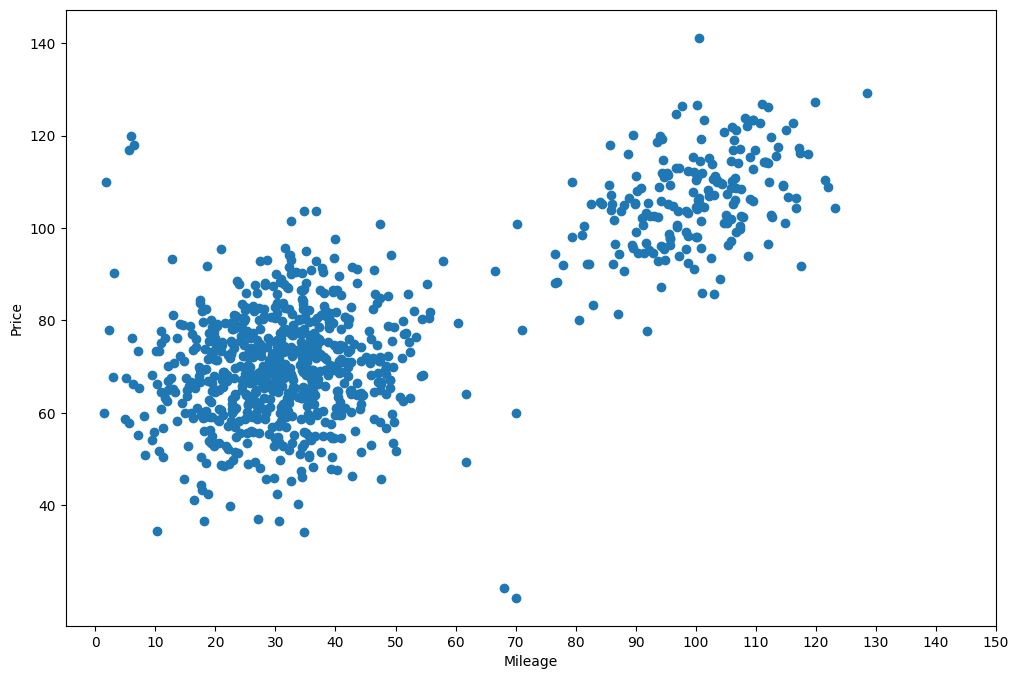

In [31]:
plt.scatter(df.Mileage, df.Price)
plt.yticks(np.arange(40,160,20))
plt.xticks(np.arange(0,160,10))
plt.xlabel('Mileage')
plt.ylabel('Price')

In [32]:
from sklearn.covariance import EllipticEnvelope
cov = EllipticEnvelope(random_state=0,contamination=0.4).fit(df)
ee_pred = cov.predict(df)

In [33]:
df['is_outlier_ee'] = ee_pred

In [34]:
cov.predict([[25, 50]])

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning:

X does not have valid feature names, but EllipticEnvelope was fitted with feature names



array([1])

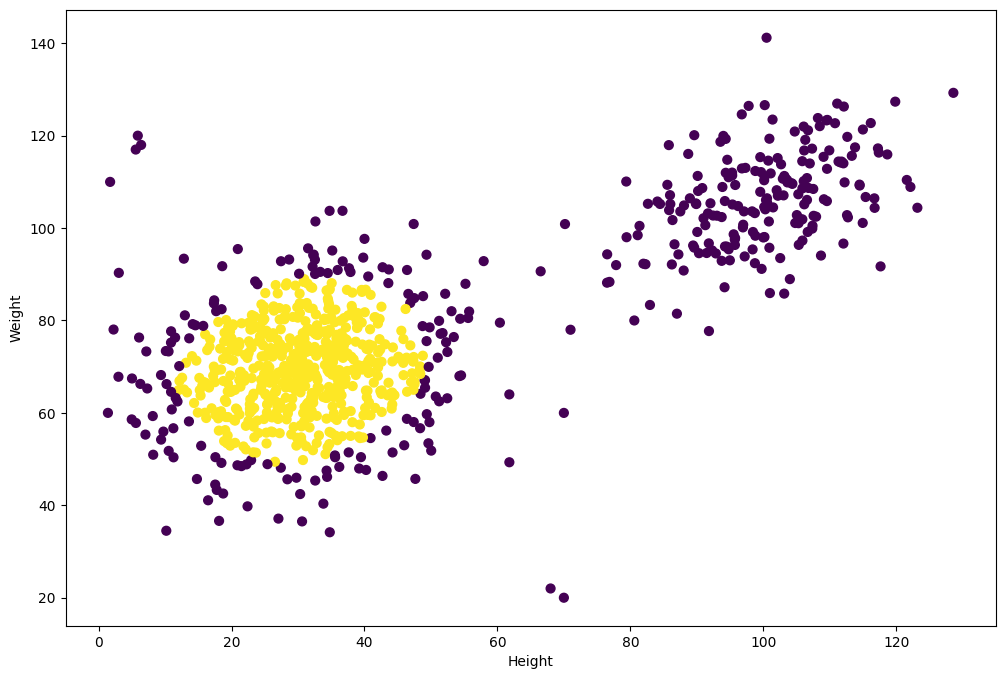

In [35]:
plt.scatter(df.Mileage, df.Price, s=40, c=df['is_outlier_ee'])
plt.xlabel('Height')
plt.ylabel('Weight')
plt.show()

#### **Disadvantages**

You might have find the concept of elliptic envelope quite straightforward, but there are limitations.

  - It cannot be used non-unimodal data
  - It is specifically for multivariate gaussians

If the data fails to meet the assumptions of unimodal and multivariate gaussian, the whole things crashes.

![](https://www.cheenta.com/wp-content/uploads/2020/07/MStat11-1024x512.jpg)